In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")


In [2]:
trader_df = pd.read_csv("csv_files/historical_data.csv")
sentiment_df = pd.read_csv("csv_files/fear_greed_index.csv")


In [3]:
trader_df.head()




,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [4]:

sentiment_df.head()


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
trader_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [6]:
sentiment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [7]:
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'], format='%Y-%m-%d')
sentiment_df['sentiment_date'] = sentiment_df['date'].dt.date


In [8]:
sentiment_df['classification'] = sentiment_df['classification'].str.strip()
sentiment_df['classification'].value_counts()


classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64

In [9]:
trader_df['Timestamp IST'] = pd.to_datetime(
    trader_df['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

trader_df['trade_date'] = trader_df['Timestamp IST'].dt.date


In [10]:
trader_df = trader_df.rename(columns={
    'Execution Price': 'execution_price',
    'Size Tokens': 'size_tokens',
    'Size USD': 'size_usd',
    'Side': 'side',
    'Closed PnL': 'closed_pnl',
    'Fee': 'fee',
    'Coin': 'coin'
})


In [11]:
trader_df['coin'].value_counts().head()


coin
HYPE    68005
@107    29992
BTC     26064
ETH     11158
SOL     10691
Name: count, dtype: int64

In [12]:
trader_df['is_profitable'] = trader_df['closed_pnl'] > 0
trader_df['abs_size_usd'] = trader_df['size_usd'].abs()


In [13]:
trader_df['net_pnl'] = trader_df['closed_pnl'] - trader_df['fee']


In [14]:
trader_df.to_csv('csv_files/cleaned_trader_data.csv', index=False)


In [15]:
merged_df = trader_df.merge(
    sentiment_df,
    left_on='trade_date',
    right_on='sentiment_date',
    how='inner'
)


In [16]:
merged_df[['trade_date', 'classification']].head()


,trade_date,classification
0,2024-12-02,Extreme Greed
1,2024-12-02,Extreme Greed
2,2024-12-02,Extreme Greed
3,2024-12-02,Extreme Greed
4,2024-12-02,Extreme Greed


In [17]:
merged_df.to_csv('csv_files/merged_sentiment_trader.csv', index=False)


In [18]:
merged_df.groupby('classification')['closed_pnl'].describe()


,count,mean,std,min,25%,50%,75%,max
classification,,,,,,,,
Extreme Fear,21400.0,34.537862,1136.056091,-31036.69194,0.0,0.0,5.635032,115287.00000
Extreme Greed,39992.0,67.892861,766.828294,-10259.46800,0.0,0.0,10.028709,44223.45187
Fear,61837.0,54.290400,935.355438,-35681.74723,0.0,0.0,5.590856,135329.09010
Greed,50303.0,42.743559,1116.028390,-117990.10410,0.0,0.0,4.944105,74530.52371
Neutral,37686.0,34.307718,517.122220,-24500.00000,0.0,0.0,3.995795,48504.09555


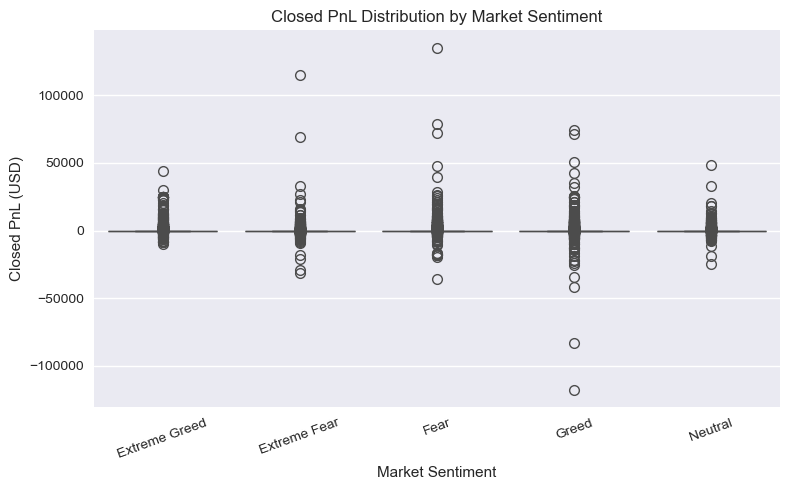

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=merged_df,
    x='classification',
    y='closed_pnl'
)
plt.title('Closed PnL Distribution by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Closed PnL (USD)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('outputs/pnl_vs_sentiment.png')
plt.show()


In [20]:
win_rate = (
    merged_df
    .groupby('classification')['is_profitable']
    .mean()
    .reset_index()
)

win_rate['win_rate_percent'] = win_rate['is_profitable'] * 100
win_rate


,classification,is_profitable,win_rate_percent
0,Extreme Fear,0.370607,37.060748
1,Extreme Greed,0.464943,46.494299
2,Fear,0.420768,42.076750
3,Greed,0.384828,38.482794
4,Neutral,0.396991,39.699093


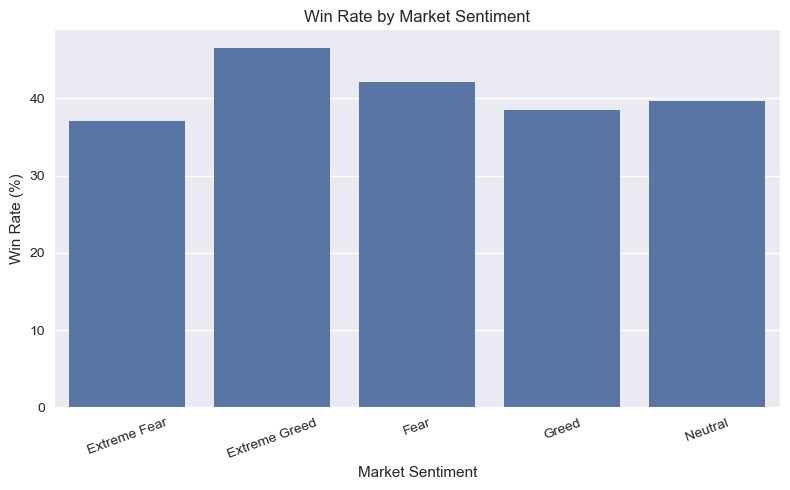

In [21]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=win_rate,
    x='classification',
    y='win_rate_percent'
)
plt.title('Win Rate by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Win Rate (%)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('outputs/win_rate_vs_sentiment.png')
plt.show()


In [22]:
merged_df.groupby('classification')['abs_size_usd'].agg(
    trade_count='count',
    avg_trade_size='mean',
    total_volume='sum'
)


,trade_count,avg_trade_size,total_volume
classification,,,
Extreme Fear,21400,5349.731843,1.144843e+08
Extreme Greed,39992,3112.251565,1.244652e+08
Fear,61837,7816.109931,4.833248e+08
Greed,50303,5736.884375,2.885825e+08
Neutral,37686,4782.732661,1.802421e+08


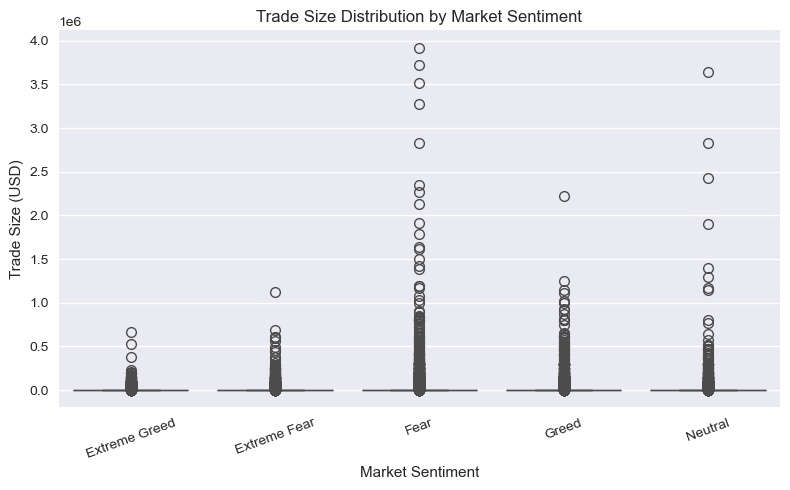

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=merged_df,
    x='classification',
    y='abs_size_usd'
)
plt.title('Trade Size Distribution by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Trade Size (USD)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('outputs/trade_size_vs_sentiment.png')
plt.show()


In [24]:
loss_df = merged_df[merged_df['closed_pnl'] < 0]


In [25]:
loss_df.groupby('classification')['closed_pnl'].mean()


classification
Extreme Fear    -257.099629
Extreme Greed   -119.920289
Fear            -156.662401
Greed           -181.967329
Neutral         -121.727849
Name: closed_pnl, dtype: float64

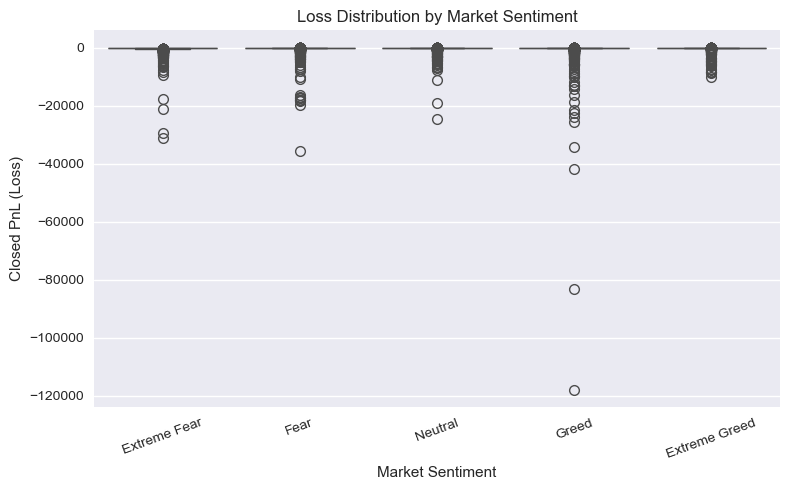

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=loss_df,
    x='classification',
    y='closed_pnl'
)
plt.title('Loss Distribution by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Closed PnL (Loss)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('outputs/loss_distribution_vs_sentiment.png')
plt.show()
